libaraies

In [19]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk
from scipy.signal import find_peaks
import seaborn as sns
from scipy.stats import wilcoxon

# Pandas display settings (optional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

load files

In [20]:
# RESP FILE PATHS
RI1_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"
BLRI_s3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"
BLRI_s4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"
RI1_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
RI2_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"
RI1_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5"
RI2_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5"
RI1_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5"
RI2_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5"
RI1_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"
RI2_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5"
RI1_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5"
RI2_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5"
RI1_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5"
RI2_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5"
RI2_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5"
RI1_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"


# BORIS CSVs (no comma at the end or it makes a tuple)
RI1_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv")
RI2_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv")
RI1_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv")
RI2_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv")
RI1_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv")
RI2_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_3_p5_3_nRB3_20250622_1102116.1.csv")
RI1_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_8_p5_1_nRB3_HEEPS.csv")
RI2_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv")
RI1_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv")
RI2_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv")
RI1_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv")
RI2_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv")
RI1_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv")
RI2_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv")
RI2_3_5_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_5_p5_4_nRB3_20250621.csv")


In [21]:
ri1_h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,  
    "RI1_2_3": RI1_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
}

In [22]:
ri2_h5_paths = {
    "RI2_3_6": RI2_3_6_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [23]:
ri1_boris_data = {
    "RI1_3_6": RI1_3_6_boris.copy(),
    "RI1_4_7": RI1_4_7_boris.copy(),
    "RI1_2_3": RI1_2_3_boris.copy(),
    "RI1_4_8": RI1_4_8_boris.copy(),
    "RI1_1_1": RI1_1_1_boris.copy(),
    "RI1_1_2": RI1_1_2_boris.copy(),
    "RI1_2_4": RI1_2_4_boris.copy(),
}


In [24]:
ri2_boris_data = {
    "RI2_3_6": RI2_3_6_boris.copy(),
    "RI2_4_7": RI2_4_7_boris.copy(),
    "RI2_2_3": RI2_2_3_boris.copy(),
    "RI2_4_8": RI2_4_8_boris.copy(),
    "RI2_1_1": RI2_1_1_boris.copy(),
    "RI2_1_2": RI2_1_2_boris.copy(),
    "RI2_2_4": RI2_2_4_boris.copy(),
    "RI2_3_5": RI2_3_5_boris.copy(),
}


load_clean_resp_signal function for loading and preprocessing respiration data:

Reads raw resp signal and metadata from .h5

Computes original sampling rate (fs)

Applies a low-pass filter before downsampling to avoid aliasing

Downsamples the signal to your target_rate (default 100 Hz)

Applies a bandpass filter (0.1–20 Hz) with NeuroKit to clean the signal further

Creates a time vector that matches the cleaned signal length and sampling rate

This function returns:
rsp_cleaned: the cleaned, filtered, downsampled respiratory signal array

time_vector: time points corresponding to each sample in seconds

target_rate: the sampling rate after downsampling (e.g., 100 Hz)

You can then pass these outputs to functions like:
get_percent_change_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_start, sniff_end)

get_delta_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_end)

In [25]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal and time vector.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate

In [26]:
h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI2_3_6": RI2_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI1_2_3": RI1_2_3_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [27]:
resp_data = {}

for label, path in h5_paths.items():
    print(f"Processing {label}...")
    signal, time, rate = load_clean_resp_signal(path)
    
    if signal is not None:
        resp_data[label] = {
            "signal": signal,
            "time": time,
            "sampling_rate": rate
        }
    else:
        print(f"Skipping {label}: failed to load.")

print("✅ All available signals loaded.")


Processing RI1_3_6...
Processing RI2_3_6...
Processing RI1_4_7...
Processing RI2_4_7...
Processing RI1_2_3...
Processing RI2_2_3...
Processing RI1_4_8...
Processing RI2_4_8...
Processing RI1_1_1...
Processing RI2_1_1...
Processing RI1_1_2...
Processing RI2_1_2...
Processing RI1_2_4...
Processing RI2_2_4...
Processing RI1_3_5...
Processing RI2_3_5...
✅ All available signals loaded.


get_sniff_respiratory_rate function is good for calculating the breathing rate during a sniff bout:

It creates a mask to select the respiratory signal samples between sniff_start and sniff_end.

It uses find_peaks to detect inhalation peaks in that signal segment, with a minimum peak distance of 0.2 seconds (to avoid counting the same breath twice).

It calculates the duration of the sniff bout.

It returns the breathing rate as the number of detected peaks divided by the duration (giving rate in Hz).

A few things to watch out for:
Sampling rate consistency: Make sure the times array and the signal array are aligned and that sampling_rate matches the sampling frequency of the signal.

Peak detection threshold: You might want to tweak the distance or add a height parameter in find_peaks if you get too many or too few peaks.

Edge cases: If duration is zero or very small, it returns np.nan, which is good.



In [28]:
def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    """
    Compute breathing rate (Hz) during a sniff bout or whole trial ie sniff_start = trial_start and sniff_end = trial_end.
    """
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]

    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.0833)  # 0.0833 seconds corresponds to 12 Hz

    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan

    return rate

In [29]:
ri_session_rates = []

for trial, entry in resp_data.items():
    signal = entry['signal']
    time = entry['time']
    sampling_rate = entry['sampling_rate']

    # Get full duration
    sniff_start = time[0]
    sniff_end = time[-1]

    # Compute respiration rate
    rate = get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=sampling_rate)

    # Get valence
    valence = 'RI1' if trial.startswith('RI1') else ('RI2' if trial.startswith('RI2') else 'Other')

    # Extract subject as 3.6 from RI1_3_6
    try:
        parts = trial.split('_')
        subject = f"{parts[1]}.{parts[2]}"
    except IndexError:
        subject = 'Unknown'

    ri_session_rates.append({
        'Trial': trial,
        'Valence': valence,
        'Subject': subject,
        'Respiration Rate (Hz)': rate
    })

# Convert to DataFrame
ri_session_df = pd.DataFrame(ri_session_rates)
print(ri_session_df.head())


     Trial Valence Subject  Respiration Rate (Hz)
0  RI1_3_6     RI1     3.6               7.270376
1  RI2_3_6     RI2     3.6               5.932787
2  RI1_4_7     RI1     4.7               7.564174
3  RI2_4_7     RI2     4.7               6.551133
4  RI1_2_3     RI1     2.3               7.285965


In [30]:
def extract_agent_body_sniffs(df):
    """
    Filters BORIS dataframe for body sniffing initiated by the social agent.
    """
    df = df.copy()
    df['Start (s)'] = df['Start (s)'].astype(float)
    df['Stop (s)'] = df['Stop (s)'].astype(float)
    df = df.sort_values(by='Start (s)').reset_index(drop=True)

    # Filter for body sniffing by the social agent
    agent_mask = df['Subject'].str.lower() == 'social_agent'
    sniff_mask = df['Behavior'].str.lower() == 'body sniffing'

    return df[agent_mask & sniff_mask]



In [31]:
all_agent_body_sniffs = []

for label, boris_df in ri1_boris_data.items():
    sniffs = extract_agent_body_sniffs(boris_df)
    sniffs["Trial"] = label
    sniffs["Group"] = "RI1"
    all_agent_body_sniffs.append(sniffs)

for label, boris_df in ri2_boris_data.items():
    sniffs = extract_agent_body_sniffs(boris_df)
    sniffs["Trial"] = label
    sniffs["Group"] = "RI2"
    all_agent_body_sniffs.append(sniffs)

combined_sniffs_df = pd.concat(all_agent_body_sniffs, ignore_index=True)


In [32]:
# Call the function on your BORIS dataframe
agent_body_sniffs = extract_agent_body_sniffs(RI2_4_7_boris)

# Optional: preview the result
print(agent_body_sniffs.head())


        Observation id         Observation date  Description Observation type  \
9   RI2_s4_7_p5_2_nRB3  2025-07-01 08:59:12.130          NaN       Media file   
11  RI2_s4_7_p5_2_nRB3  2025-07-01 08:59:12.130          NaN       Media file   
19  RI2_s4_7_p5_2_nRB3  2025-07-01 08:59:12.130          NaN       Media file   
22  RI2_s4_7_p5_2_nRB3  2025-07-01 08:59:12.130          NaN       Media file   
32  RI2_s4_7_p5_2_nRB3  2025-07-01 08:59:12.130          NaN       Media file   

                                                                                            Source  \
9   player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4   
11  player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4   
19  player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4   
22  player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI2_s4_7_p5_2_nRB3_20250621_152519.1.mp4   
32 

ONE SUBJECT 3.6 WORKED

RUN LOOP ON ALL SUBJECTS WORKS

In [33]:
# List to collect all social agent-initiated body sniffs
all_agent_body_sniffs = []

# Loop through RI1 trials
for label, boris_df in ri1_boris_data.items():
    body_sniffs = extract_agent_body_sniffs(boris_df)  # <-- updated function for body sniffing
    body_sniffs["Trial"] = label
    body_sniffs["Group"] = "RI1"
    all_agent_body_sniffs.append(body_sniffs)

# Loop through RI2 trials
for label, boris_df in ri2_boris_data.items():
    body_sniffs = extract_agent_body_sniffs(boris_df)  # <-- updated function for body sniffing
    body_sniffs["Trial"] = label
    body_sniffs["Group"] = "RI2"
    all_agent_body_sniffs.append(body_sniffs)

# Combine all into one DataFrame
combined_body_sniffs_df = pd.concat(all_agent_body_sniffs, ignore_index=True)



In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def calculate_percent_change_resp_body_sniff_with_post(signal, time, sniff_start, sampling_rate=100, plot=True,
                                                       baseline_color='gray', sniff_color='orange',
                                                       post_color='green', title=None):
    """
    Calculates % change in respiration rate (Hz) during and after a body sniff event compared to baseline.

    Time Windows:
    - Baseline:     -5s to -1s before sniff_start (4 sec)
    - During Sniff:  0s to +0.5s after sniff_start (0.5 sec)
    - Post Sniff:    +0.5s to +1.5s after sniff_start (1.0 sec)

    Returns:
        percent_change_sniff: % change from baseline to during sniff
        percent_change_post: % change from baseline to post-sniff
        baseline_mean_rate: mean respiration rate in baseline window (Hz)
        sniff_mean_rate: mean rate during sniff (Hz)
        post_mean_rate: mean rate post-sniff (Hz)
    """
    # Define time masks
    baseline_mask = (time >= sniff_start - 5) & (time < sniff_start - 1)
    sniff_mask = (time >= sniff_start) & (time < sniff_start + 0.5)
    post_mask = (time >= sniff_start + 0.5) & (time < sniff_start + 1.5)

    # Extract segments
    baseline_segment = signal[baseline_mask]
    sniff_segment = signal[sniff_mask]
    post_segment = signal[post_mask]

    # Define minimum spacing between breaths (~75 ms)
    min_distance_samples = int(0.0833 * sampling_rate)

    # Find peaks (breaths)
    baseline_peaks, _ = find_peaks(baseline_segment, distance=min_distance_samples)
    sniff_peaks, _ = find_peaks(sniff_segment, distance=min_distance_samples)
    post_peaks, _ = find_peaks(post_segment, distance=min_distance_samples)

    # Get time values for those peaks
    baseline_peak_times = time[baseline_mask][baseline_peaks]
    sniff_peak_times = time[sniff_mask][sniff_peaks]
    post_peak_times = time[post_mask][post_peaks]

    # Calculate inter-breath intervals (IBIs)
    baseline_ibis = np.diff(baseline_peak_times)
    sniff_ibis = np.diff(sniff_peak_times)
    post_ibis = np.diff(post_peak_times)

    # Abort if any region lacks sufficient data
    if len(baseline_ibis) == 0 or len(sniff_ibis) == 0 or len(post_ibis) == 0:
        if plot:
            print("⚠️ Not enough peaks detected in one or more windows.")
        return None, None, None, None, None

    # Convert to Hz
    baseline_rates = 1 / baseline_ibis
    sniff_rates = 1 / sniff_ibis
    post_rates = 1 / post_ibis

    # Mean rates
    baseline_mean_rate = np.mean(baseline_rates)
    sniff_mean_rate = np.mean(sniff_rates)
    post_mean_rate = np.mean(post_rates)

    # Percent changes
    percent_change_sniff = ((sniff_mean_rate - baseline_mean_rate) / baseline_mean_rate) * 100
    percent_change_post = ((post_mean_rate - baseline_mean_rate) / baseline_mean_rate) * 100

    if plot:
        plt.figure(figsize=(6, 4))
        plt.bar(['Baseline (−5 to −1 s)', 'During Sniff (0–0.5 s)', 'Post Sniff (0.5–1.5 s)'],
                [baseline_mean_rate, sniff_mean_rate, post_mean_rate],
                color=[baseline_color, sniff_color, post_color])
        plt.ylabel('Respiration Rate (Hz)')
        plt.xticks(rotation=15)
        if title:
            plt.title(title)
        else:
            plt.title(f'RR Change (Body Sniff)\nDuring: {percent_change_sniff:.1f}%, Post: {percent_change_post:.1f}%')
        plt.tight_layout()
        plt.show()

    return percent_change_sniff, percent_change_post, baseline_mean_rate, sniff_mean_rate, post_mean_rate


In [38]:
results_body_sniff = []

for i, sniff_row in combined_sniffs_df.iterrows():
    trial = sniff_row["Trial"]
    sniff_start = sniff_row["Start (s)"]

    # Fetch respiration data for this trial
    resp_entry = resp_data.get(trial)
    if resp_entry is None:
        print(f"Missing respiration data for {trial}, skipping...")
        continue

    signal = resp_entry["signal"]
    time = resp_entry["time"]
    sampling_rate = resp_entry["sampling_rate"]

    # Use updated function with post-sniff analysis
    pct_change_sniff, pct_change_post, baseline_rate, sniff_rate, post_rate = calculate_percent_change_resp_body_sniff_with_post(
        signal, time, sniff_start, sampling_rate=sampling_rate, plot=False
    )

    if pct_change_sniff is None:
        print(f"Not enough peaks for sniff at {sniff_start}s in {trial}, skipping...")
        continue

    results_body_sniff.append({
        "Trial": trial,
        "Sniff Start": sniff_start,
        "Percent Change Sniff": pct_change_sniff,
        "Percent Change Post": pct_change_post,
        "Baseline Rate": baseline_rate,
        "Sniff Rate": sniff_rate,
        "Post Rate": post_rate
    })

# Convert to DataFrame
results_body_df = pd.DataFrame(results_body_sniff)
print(results_body_df.head())



Not enough peaks for sniff at 455.067s in RI2_3_6, skipping...
     Trial  Sniff Start  Percent Change Sniff  Percent Change Post  \
0  RI1_3_6      404.310             -1.716389            31.598582   
1  RI1_3_6      596.931             38.028056            15.802857   
2  RI1_2_3       75.723            -14.230146           -13.305074   
3  RI1_2_3       80.222             11.670782             4.612802   
4  RI1_2_3      145.222            -18.648124             2.871655   

   Baseline Rate  Sniff Rate  Post Rate  
0       6.177458    6.071429   8.129447  
1       7.647399   10.555556   8.855906  
2      11.129149    9.545455   9.648407  
3       9.328014   10.416667   9.758297  
4       7.230753    5.882353   7.438395  


C:\Users\sjs93\AppData\Local\Temp\ipykernel_49852\2837720076.py:46: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.swarmplot(


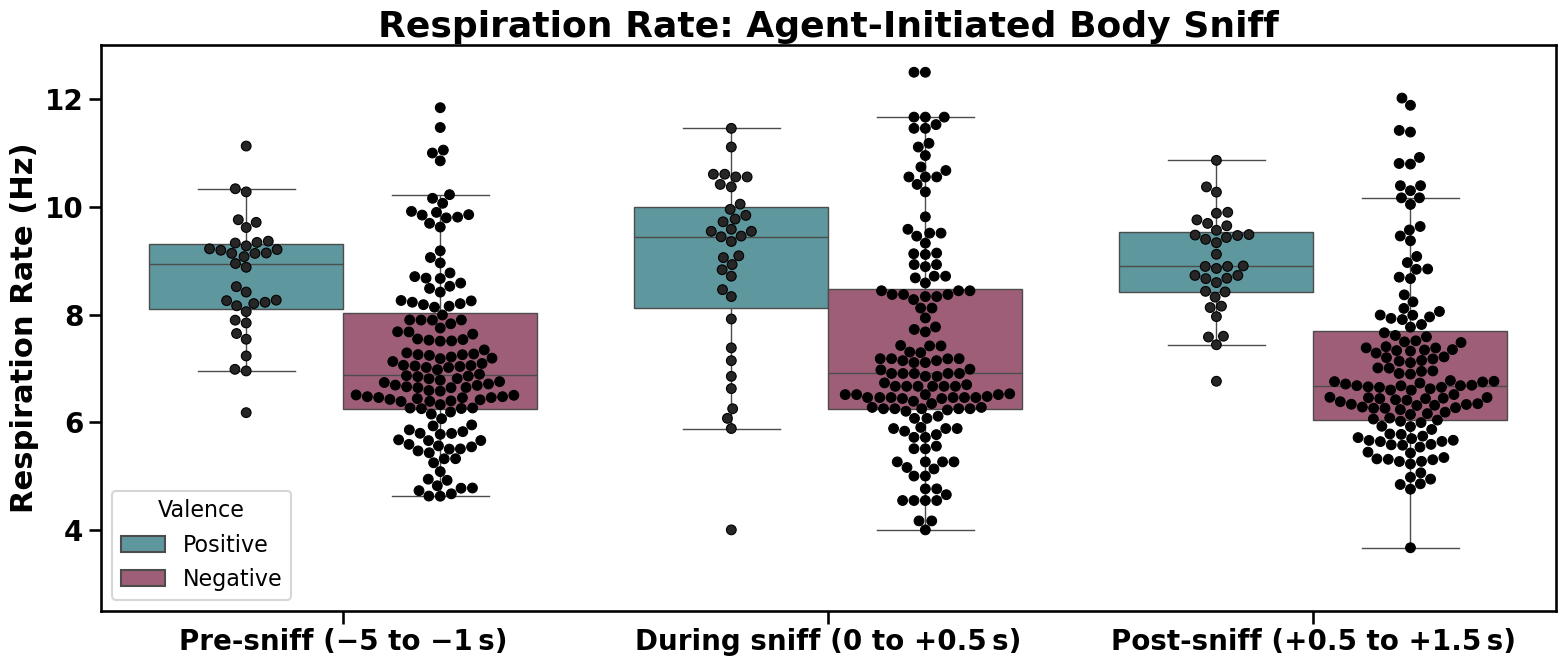

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define color palette
custom_palette = {
    'Positive': (83/255, 161/255, 169/255),  # RI1
    'Negative': (169/255, 83/255, 118/255)   # RI2
}

# Label valence based on Trial
results_body_df['Valence'] = results_body_df['Trial'].apply(
    lambda x: 'Positive' if 'RI1' in x else ('Negative' if 'RI2' in x else 'Unknown')
)
results_body_df = results_body_df[results_body_df['Valence'] != 'Unknown']

# Melt dataframe for Pre, During, and Post sniff plotting
plot_df = results_body_df.melt(
    id_vars=["Trial", "Sniff Start", "Valence"],
    value_vars=["Baseline Rate", "Sniff Rate", "Post Rate"],
    var_name="Condition",
    value_name="Respiration Rate (Hz)"
)

# Rename time window labels for clarity
plot_df["Condition"] = plot_df["Condition"].replace({
    "Baseline Rate": "Pre-sniff (−5 to −1 s)",
    "Sniff Rate": "During sniff (0 to +0.5 s)",
    "Post Rate": "Post-sniff (+0.5 to +1.5 s)"
})

# Initialize figure
plt.figure(figsize=(16, 7))
sns.set_context("talk")

# Boxplot for central tendency
sns.boxplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    palette=custom_palette,
    fliersize=0
)

# Swarmplot for individual points
sns.swarmplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    dodge=True,
    color='black',
    edgecolor='black',
    alpha=1,
    size=7,
    marker='o',
    linewidth=0.8,
    legend=False
)

# Format plot
plt.title("Respiration Rate: Agent-Initiated Body Sniff", fontsize=26, weight='bold')
plt.ylabel("Respiration Rate (Hz)", fontsize=22, weight='bold')
plt.xlabel('')
plt.xticks(fontsize=20, weight='bold')
plt.yticks(ticks=[4, 6, 8, 10, 12],fontsize=20, weight='bold')
plt.ylim(2.5, 13)

plt.legend(title='Valence', fontsize=16, title_fontsize=16, loc='lower left', bbox_to_anchor=(0, 0))
plt.tight_layout()
plt.show()
